# SuperbCommand – Multi-Asset CTA Strategy
## Notebook 11 — Walk-Forward Asset-Class Strategy Selection

**Purpose:** test whether strategy specialisation by asset class survives strict sequential out-of-sample evaluation.

Notebook 10 suggested that:

- equities may favour SuperbCommand;
- commodities, rates, FX and crypto often favour Dual Trend or other simpler rules;
- strategy leadership changes through time.

Notebook 11 therefore asks:

> **Can we choose the most suitable strategy for each asset class using only prior information, then combine those selected sleeves into a diversified portfolio without using hindsight?**

### Candidate strategies within each asset class

The same five pre-declared strategies are retained:

1. `SC_CORE`
2. `SC_PT_REDUCE_25`
3. `DUAL_TREND_13_52`
4. `TSMOM_52W`
5. `PASSIVE_LONG`

No signal hyperparameters are changed.

### Walk-forward framework

For each asset class separately:

1. evaluate the five strategies using only the trailing training window;
2. select one strategy;
3. hold that strategy assignment for the next calendar year;
4. repeat annually.

Three training windows are tested as robustness checks:

- 3 years
- 5 years
- 7 years

The **5-year selector** remains the primary specification.

### Selection rules

Two pre-specified selection methods are tested:

**Sharpe selector**
- rank by training Sharpe;
- Calmar is the deterministic tie-breaker.

**Balanced selector**
- rank each strategy within the asset class by:
  - Sharpe
  - Sortino
  - Calmar
- average the three ranks;
- lower average rank wins;
- Sharpe is the deterministic tie-breaker.

This tests whether a more conservative risk-adjusted selection rule is more robust than pure Sharpe chasing.

### Portfolio construction

After choosing one strategy per asset class for each year, the asset-class sleeves are combined using **hierarchical inverse-volatility weights** estimated only from prior returns.

This preserves the portfolio-construction lesson from Notebooks 05–10 while preventing look-ahead.

### Benchmarks

Compare the dynamic specialist architecture against:

- pure Dual Trend + hierarchical inverse vol;
- pure TSMOM + hierarchical inverse vol;
- passive + hierarchical inverse vol;
- the Notebook 08 portfolio-level WF blend selector.

### Final holdout

Research ends on:

**31 December 2025**

The entire 2026 period remains untouched.


In [1]:
# ============================================================
# 11.1 — IMPORTS, DRIVE & PROJECT CONFIGURATION
# ============================================================
from __future__ import annotations

import json
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from google.colab import drive
    drive.mount("/content/drive")
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

PROJECT_ROOT = (
    Path("/content/drive/MyDrive/Colab Notebooks/SuperbCommand/Multi-Asset CTA Strategy")
    if IN_COLAB
    else Path.cwd() / "Multi-Asset CTA Strategy"
)

CONFIG_PATH = PROJECT_ROOT / "config" / "project_config.json"
if not CONFIG_PATH.exists():
    raise FileNotFoundError("Run Notebook 00 first.")

with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    CFG = json.load(f)

PATHS = {k: Path(v) for k, v in CFG["paths"].items()}

RESEARCH_END = pd.Timestamp(CFG["research_dates"]["research_end"])
HOLDOUT_START = pd.Timestamp(CFG["research_dates"]["holdout_start"])

if CFG["research_dates"]["unlock_holdout"]:
    raise RuntimeError("Notebook 11 cannot run with the 2026 holdout unlocked.")

AC_RETURNS_PATH = PATHS["data_processed"] / "10_asset_class_strategy_return_panel.parquet"
BASELINE_PATH = PATHS["data_processed"] / "06_baseline_return_panel.parquet"
WF_BLEND_PATH = PATHS["data_processed"] / "08_composite_walkforward_return.parquet"

for p in [AC_RETURNS_PATH, BASELINE_PATH, WF_BLEND_PATH]:
    if not p.exists():
        raise FileNotFoundError(f"Required upstream file not found: {p}")

print("Project:", PROJECT_ROOT)
print("Research cutoff:", RESEARCH_END.date())
print("2026 holdout: LOCKED")


Mounted at /content/drive
Project: /content/drive/MyDrive/Colab Notebooks/SuperbCommand/Multi-Asset CTA Strategy
Research cutoff: 2025-12-31
2026 holdout: LOCKED


In [2]:
# ============================================================
# 11.2 — LOAD ASSET-CLASS STRATEGY RETURNS
# ============================================================
ac_panel = pd.read_parquet(AC_RETURNS_PATH)
baseline_panel = pd.read_parquet(BASELINE_PATH)
wf_blend_df = pd.read_parquet(WF_BLEND_PATH)

if ac_panel.index.max() >= HOLDOUT_START:
    raise RuntimeError("Holdout contamination in asset-class return panel.")
if baseline_panel.index.max() >= HOLDOUT_START:
    raise RuntimeError("Holdout contamination in benchmark panel.")
if wf_blend_df.index.max() >= HOLDOUT_START:
    raise RuntimeError("Holdout contamination in WF blend panel.")

asset_classes = sorted(ac_panel.columns.get_level_values("asset_class").unique())
strategies = sorted(ac_panel.columns.get_level_values("strategy").unique())

EXPECTED_STRATEGIES = {
    "SC_CORE",
    "SC_PT_REDUCE_25",
    "DUAL_TREND_13_52",
    "TSMOM_52W",
    "PASSIVE_LONG",
}

if set(strategies) != EXPECTED_STRATEGIES:
    raise RuntimeError(
        f"Unexpected strategy set. Found {strategies}, expected {sorted(EXPECTED_STRATEGIES)}"
    )

print("Asset classes:", asset_classes)
print("Strategies:", strategies)
print("Panel:", ac_panel.shape)
display(ac_panel.tail())


Asset classes: ['commodities', 'crypto', 'equities', 'fx', 'rates']
Strategies: ['DUAL_TREND_13_52', 'PASSIVE_LONG', 'SC_CORE', 'SC_PT_REDUCE_25', 'TSMOM_52W']
Panel: (1095, 25)


asset_class commodities                                             \
strategy        SC_CORE SC_PT_REDUCE_25 DUAL_TREND_13_52 TSMOM_52W   
date                                                                 
2025-11-28     0.029944        0.029944         0.029944  0.029944   
2025-12-05     0.003998        0.003998         0.003998  0.003998   
2025-12-12     0.002858        0.002858         0.002858  0.002858   
2025-12-19     0.003000        0.003000         0.003000  0.003000   
2025-12-26     0.035640        0.035640         0.035640  0.035640   

asset_class                 crypto                                             \
strategy    PASSIVE_LONG   SC_CORE SC_PT_REDUCE_25 DUAL_TREND_13_52 TSMOM_52W   
date                                                                            
2025-11-28      0.029944  0.068498        0.068498              0.0       0.0   
2025-12-05      0.003998 -0.016845       -0.016845              0.0       0.0   
2025-12-12      0.002858  0.009874        0.009874              0.0       0.0   
2025-12-19      0.003000 -0.024006       -0.024006              0.0       0.0   
2025-12-26      0.035640 -0.009102       -0.009102              0.0       0.0   

asset_class               ...        fx                                   \
strategy    PASSIVE_LONG  ...   SC_CORE SC_PT_REDUCE_25 DUAL_TREND_13_52   
date                      ...                                              
2025-11-28      0.068498  ... -0.006640       -0.006640        -0.003170   
2025-12-05     -0.016845  ... -0.004608       -0.004608        -0.002304   
2025-12-12      0.009874  ... -0.004630       -0.004630        -0.002315   
2025-12-19     -0.024006  ...  0.004293        0.004293         0.002147   
2025-12-26     -0.009102  ... -0.006374       -0.006374        -0.003187   

asset_class                            rates                                   \
strategy    TSMOM_52W PASSIVE_LONG   SC_CORE SC_PT_REDUCE_25 DUAL_TREND_13_52   
date                                                                            
2025-11-28        0.0    -0.006340  0.003472        0.003299         0.003472   
2025-12-05        0.0    -0.004608 -0.007973       -0.007652        -0.007973   
2025-12-12        0.0    -0.004630 -0.003275       -0.003226        -0.001849   
2025-12-19        0.0     0.004293  0.003072        0.002520         0.002225   
2025-12-26        0.0    -0.006374  0.001403        0.001081         0.001007   

asset_class                         
strategy    TSMOM_52W PASSIVE_LONG  
date                                
2025-11-28   0.003472     0.003472  
2025-12-05  -0.007973    -0.007973  
2025-12-12  -0.000921    -0.003275  
2025-12-19   0.003072     0.003072  
2025-12-26   0.001403     0.001403  

[5 rows x 25 columns]

## 11.3 Performance functions


In [3]:
# ============================================================
# 11.3 — PERFORMANCE FUNCTIONS
# ============================================================
WEEKS_PER_YEAR = 52

def max_drawdown(r):
    r = pd.Series(r).dropna()
    if len(r) == 0:
        return np.nan
    eq = (1 + r).cumprod()
    return float((eq / eq.cummax() - 1).min())

def cagr(r):
    r = pd.Series(r).dropna()
    if len(r) == 0:
        return np.nan
    wealth = float((1 + r).prod())
    years = len(r) / WEEKS_PER_YEAR
    if wealth <= 0 or years <= 0:
        return np.nan
    return wealth ** (1 / years) - 1

def ann_vol(r):
    r = pd.Series(r).dropna()
    if len(r) < 2:
        return np.nan
    return float(r.std(ddof=1) * np.sqrt(WEEKS_PER_YEAR))

def sharpe(r):
    r = pd.Series(r).dropna()
    if len(r) < 2 or r.std(ddof=1) == 0:
        return np.nan
    return float(r.mean() / r.std(ddof=1) * np.sqrt(WEEKS_PER_YEAR))

def sortino(r):
    r = pd.Series(r).dropna()
    d = r[r < 0]
    if len(d) < 2 or d.std(ddof=1) == 0:
        return np.nan
    return float(r.mean() / d.std(ddof=1) * np.sqrt(WEEKS_PER_YEAR))

def calmar(r):
    ca = cagr(r)
    md = max_drawdown(r)
    if pd.isna(ca) or pd.isna(md) or md == 0:
        return np.nan
    return float(ca / abs(md))

def metrics(r):
    r = pd.Series(r).dropna()
    return {
        "weeks": len(r),
        "cagr": cagr(r),
        "ann_vol": ann_vol(r),
        "sharpe": sharpe(r),
        "sortino": sortino(r),
        "max_drawdown": max_drawdown(r),
        "calmar": calmar(r),
        "worst_week": r.min() if len(r) else np.nan,
        "positive_week_rate": (r > 0).mean() if len(r) else np.nan,
    }


## 11.4 Strategy-selection functions

The selector operates **within each asset class**.

No strategy can be selected using information from the subsequent test year.


In [4]:
# ============================================================
# 11.4 — STRATEGY-SELECTION FUNCTIONS
# ============================================================
def strategy_training_table(train_df):
    rows = []

    for strategy in strategies:
        r = train_df[strategy]
        m = metrics(r)

        rows.append({
            "strategy": strategy,
            "weeks": m["weeks"],
            "sharpe": m["sharpe"],
            "sortino": m["sortino"],
            "calmar": m["calmar"],
            "cagr": m["cagr"],
            "max_drawdown": m["max_drawdown"],
        })

    return pd.DataFrame(rows)

def select_by_sharpe(train_df):
    table = strategy_training_table(train_df).copy()

    table["sharpe_rank_value"] = table["sharpe"].fillna(-np.inf)
    table["calmar_rank_value"] = table["calmar"].fillna(-np.inf)

    table = table.sort_values(
        ["sharpe_rank_value", "calmar_rank_value", "strategy"],
        ascending=[False, False, True],
    ).reset_index(drop=True)

    return table.iloc[0]["strategy"], table

def select_balanced(train_df):
    table = strategy_training_table(train_df).copy()

    for metric in ["sharpe", "sortino", "calmar"]:
        table[f"{metric}_rank"] = (
            table[metric]
            .rank(method="average", ascending=False, na_option="bottom")
        )

    table["mean_rank"] = table[
        ["sharpe_rank", "sortino_rank", "calmar_rank"]
    ].mean(axis=1)

    table["sharpe_rank_value"] = table["sharpe"].fillna(-np.inf)

    table = table.sort_values(
        ["mean_rank", "sharpe_rank_value", "strategy"],
        ascending=[True, False, True],
    ).reset_index(drop=True)

    return table.iloc[0]["strategy"], table


## 11.5 Asset-class inverse-vol portfolio weights

For every test year, asset-class weights are estimated from the training-period returns of the **selected sleeves**.

For selected asset-class return series \(r_c\):

\[
w_c
\propto
\frac{1}{\sigma_c}
\]

and:

\[
\sum_c w_c = 1
\]

The selected strategy determines the sleeve return; inverse volatility determines how much capital the sleeve receives.

This is estimated using training data only.


In [5]:
# ============================================================
# 11.5 — INVERSE-VOL ASSET-CLASS WEIGHTS
# ============================================================
def inverse_vol_weights(selected_training_returns, min_vol=1e-8):
    vols = selected_training_returns.std(ddof=1) * np.sqrt(WEEKS_PER_YEAR)
    inv = 1 / vols.clip(lower=min_vol)

    inv = inv.replace([np.inf, -np.inf], np.nan).dropna()

    if len(inv) == 0 or inv.sum() <= 0:
        return pd.Series(
            1 / selected_training_returns.shape[1],
            index=selected_training_returns.columns,
        )

    return inv / inv.sum()


## 11.6 Walk-forward engine

For each test year and each asset class:

1. build a training sample from prior calendar years;
2. select the winning strategy;
3. collect that strategy's training return series;
4. estimate cross-asset-class inverse-vol weights;
5. apply the selected strategies and fixed weights throughout the next year.

The weights and strategy choices are both frozen for the entire test year.


In [6]:
# ============================================================
# 11.6 — WALK-FORWARD SPECIALIST ENGINE
# ============================================================
def run_specialist_selector(
    training_years=5,
    selector="sharpe",
    first_test_year=2011,
    last_test_year=2025,
):
    selector_func = {
        "sharpe": select_by_sharpe,
        "balanced": select_balanced,
    }[selector]

    selection_rows = []
    weight_rows = []
    yearly_return_pieces = []

    for test_year in range(first_test_year, last_test_year + 1):
        train_start_year = test_year - training_years
        train_end_year = test_year - 1

        selected_map = {}
        selected_training = {}
        selected_testing = {}

        for asset_class in asset_classes:
            block = ac_panel[asset_class]

            train = block[
                (block.index.year >= train_start_year)
                & (block.index.year <= train_end_year)
            ]

            test = block[
                block.index.year == test_year
            ]

            selected_strategy, rank_table = selector_func(train)

            selected_map[asset_class] = selected_strategy
            selected_training[asset_class] = train[selected_strategy]
            selected_testing[asset_class] = test[selected_strategy]

            winner = rank_table.iloc[0]

            selection_rows.append({
                "training_years": training_years,
                "selector": selector,
                "test_year": test_year,
                "train_start_year": train_start_year,
                "train_end_year": train_end_year,
                "asset_class": asset_class,
                "selected_strategy": selected_strategy,
                "selected_train_sharpe": winner.get("sharpe", np.nan),
                "selected_train_sortino": winner.get("sortino", np.nan),
                "selected_train_calmar": winner.get("calmar", np.nan),
                "selected_mean_rank": winner.get("mean_rank", np.nan),
            })

        train_matrix = pd.concat(selected_training, axis=1)
        test_matrix = pd.concat(selected_testing, axis=1)

        weights = inverse_vol_weights(train_matrix)

        for asset_class, weight in weights.items():
            weight_rows.append({
                "training_years": training_years,
                "selector": selector,
                "test_year": test_year,
                "asset_class": asset_class,
                "weight": weight,
                "selected_strategy": selected_map[asset_class],
            })

        test_matrix = test_matrix.reindex(columns=weights.index)
        portfolio_return = (test_matrix * weights).sum(axis=1, min_count=1)
        portfolio_return.name = test_year

        yearly_return_pieces.append(portfolio_return)

    returns = pd.concat(yearly_return_pieces).sort_index()
    selections = pd.DataFrame(selection_rows)
    weights = pd.DataFrame(weight_rows)

    return returns, selections, weights


## 11.7 Primary 5-year walk-forward selectors

The primary comparison is:

- 5-year Sharpe selector
- 5-year balanced selector

Both use 1-year OOS test periods.


In [7]:
# ============================================================
# 11.7 — RUN PRIMARY 5-YEAR SELECTORS
# ============================================================
PRIMARY_TRAIN_YEARS = 5
FIRST_TEST_YEAR = 2011
LAST_TEST_YEAR = 2025

wf_sharpe_5y, sel_sharpe_5y, w_sharpe_5y = run_specialist_selector(
    training_years=PRIMARY_TRAIN_YEARS,
    selector="sharpe",
    first_test_year=FIRST_TEST_YEAR,
    last_test_year=LAST_TEST_YEAR,
)

wf_balanced_5y, sel_balanced_5y, w_balanced_5y = run_specialist_selector(
    training_years=PRIMARY_TRAIN_YEARS,
    selector="balanced",
    first_test_year=FIRST_TEST_YEAR,
    last_test_year=LAST_TEST_YEAR,
)

primary_returns = pd.concat(
    {
        "AC_WF_SHARPE_5Y": wf_sharpe_5y,
        "AC_WF_BALANCED_5Y": wf_balanced_5y,
    },
    axis=1
)

display(primary_returns.tail())


,AC_WF_SHARPE_5Y,AC_WF_BALANCED_5Y
date,,
2025-11-28,0.011964,0.011753
2025-12-05,-0.002460,-0.002609
2025-12-12,0.000147,0.000212
2025-12-19,0.001473,0.001367
2025-12-26,0.008074,0.007901


## 11.8 Primary walk-forward performance


In [8]:
# ============================================================
# 11.8 — PRIMARY PERFORMANCE
# ============================================================
primary_perf_rows = []

for name in primary_returns.columns:
    primary_perf_rows.append({
        "strategy": name,
        **metrics(primary_returns[name]),
    })

primary_performance = pd.DataFrame(primary_perf_rows).sort_values(
    "sharpe",
    ascending=False
)

display(primary_performance)


,strategy,weeks,cagr,ann_vol,sharpe,sortino,max_drawdown,calmar,worst_week,positive_week_rate
0,AC_WF_SHARPE_5Y,782,0.043835,0.038742,1.127189,1.450657,-0.061874,0.708445,-0.044242,0.598465
1,AC_WF_BALANCED_5Y,782,0.041010,0.038099,1.074387,1.369555,-0.061874,0.662793,-0.044242,0.590793


## 11.9 Strategy-selection maps

These tables show which strategy each asset class receives in each test year.

A useful selector should not simply flip strategies randomly every year.


In [9]:
# ============================================================
# 11.9 — STRATEGY-SELECTION MAPS
# ============================================================
selection_map_sharpe = sel_sharpe_5y.pivot(
    index="test_year",
    columns="asset_class",
    values="selected_strategy",
)

selection_map_balanced = sel_balanced_5y.pivot(
    index="test_year",
    columns="asset_class",
    values="selected_strategy",
)

print("5Y Sharpe selector")
display(selection_map_sharpe)

print("5Y Balanced selector")
display(selection_map_balanced)


5Y Sharpe selector


asset_class,commodities,crypto,equities,fx,rates
test_year,,,,,
2011,DUAL_TREND_13_52,DUAL_TREND_13_52,TSMOM_52W,PASSIVE_LONG,DUAL_TREND_13_52
2012,DUAL_TREND_13_52,DUAL_TREND_13_52,SC_PT_REDUCE_25,DUAL_TREND_13_52,DUAL_TREND_13_52
2013,DUAL_TREND_13_52,DUAL_TREND_13_52,SC_PT_REDUCE_25,PASSIVE_LONG,SC_PT_REDUCE_25
2014,PASSIVE_LONG,DUAL_TREND_13_52,PASSIVE_LONG,PASSIVE_LONG,TSMOM_52W
2015,DUAL_TREND_13_52,PASSIVE_LONG,PASSIVE_LONG,PASSIVE_LONG,PASSIVE_LONG
2016,TSMOM_52W,DUAL_TREND_13_52,PASSIVE_LONG,DUAL_TREND_13_52,TSMOM_52W
2017,SC_PT_REDUCE_25,DUAL_TREND_13_52,PASSIVE_LONG,PASSIVE_LONG,PASSIVE_LONG
2018,TSMOM_52W,DUAL_TREND_13_52,DUAL_TREND_13_52,PASSIVE_LONG,PASSIVE_LONG
2019,TSMOM_52W,DUAL_TREND_13_52,SC_CORE,DUAL_TREND_13_52,PASSIVE_LONG


5Y Balanced selector


asset_class,commodities,crypto,equities,fx,rates
test_year,,,,,
2011,DUAL_TREND_13_52,DUAL_TREND_13_52,TSMOM_52W,SC_PT_REDUCE_25,DUAL_TREND_13_52
2012,DUAL_TREND_13_52,DUAL_TREND_13_52,SC_PT_REDUCE_25,DUAL_TREND_13_52,DUAL_TREND_13_52
2013,DUAL_TREND_13_52,DUAL_TREND_13_52,SC_PT_REDUCE_25,PASSIVE_LONG,DUAL_TREND_13_52
2014,PASSIVE_LONG,DUAL_TREND_13_52,PASSIVE_LONG,PASSIVE_LONG,DUAL_TREND_13_52
2015,DUAL_TREND_13_52,PASSIVE_LONG,PASSIVE_LONG,PASSIVE_LONG,PASSIVE_LONG
2016,TSMOM_52W,DUAL_TREND_13_52,PASSIVE_LONG,DUAL_TREND_13_52,TSMOM_52W
2017,TSMOM_52W,DUAL_TREND_13_52,PASSIVE_LONG,PASSIVE_LONG,PASSIVE_LONG
2018,TSMOM_52W,DUAL_TREND_13_52,DUAL_TREND_13_52,PASSIVE_LONG,PASSIVE_LONG
2019,TSMOM_52W,DUAL_TREND_13_52,SC_CORE,DUAL_TREND_13_52,PASSIVE_LONG


## 11.10 Selection stability by asset class

Measure:

- number of strategy changes;
- switching rate;
- number of distinct strategies used;
- most frequently selected strategy.


In [10]:
# ============================================================
# 11.10 — SELECTION STABILITY
# ============================================================
def selection_stability(selection_df):
    rows = []

    for asset_class, g in selection_df.sort_values("test_year").groupby("asset_class"):
        choices = g["selected_strategy"].tolist()

        switches = sum(
            a != b
            for a, b in zip(choices[:-1], choices[1:])
        )

        mode_strategy = pd.Series(choices).mode().iloc[0]

        rows.append({
            "asset_class": asset_class,
            "test_years": len(choices),
            "switches": switches,
            "switch_rate": switches / max(len(choices) - 1, 1),
            "unique_strategies": len(set(choices)),
            "most_selected_strategy": mode_strategy,
            "most_selected_share": choices.count(mode_strategy) / len(choices),
        })

    return pd.DataFrame(rows)

stability_sharpe = selection_stability(sel_sharpe_5y)
stability_balanced = selection_stability(sel_balanced_5y)

print("Sharpe selector")
display(stability_sharpe)

print("Balanced selector")
display(stability_balanced)


Sharpe selector


,asset_class,test_years,switches,switch_rate,unique_strategies,most_selected_strategy,most_selected_share
0,commodities,15,8,0.571429,4,DUAL_TREND_13_52,0.533333
1,crypto,15,4,0.285714,3,DUAL_TREND_13_52,0.600000
2,equities,15,8,0.571429,5,PASSIVE_LONG,0.333333
3,fx,15,8,0.571429,4,PASSIVE_LONG,0.400000
4,rates,15,6,0.428571,4,PASSIVE_LONG,0.466667


Balanced selector


,asset_class,test_years,switches,switch_rate,unique_strategies,most_selected_strategy,most_selected_share
0,commodities,15,5,0.357143,4,DUAL_TREND_13_52,0.600000
1,crypto,15,4,0.285714,3,DUAL_TREND_13_52,0.600000
2,equities,15,7,0.500000,5,SC_PT_REDUCE_25,0.400000
3,fx,15,8,0.571429,5,DUAL_TREND_13_52,0.333333
4,rates,15,4,0.285714,3,PASSIVE_LONG,0.466667


## 11.11 Dynamic asset-class weights

Inspect the inverse-vol allocation generated after strategy selection.

This reveals whether the strategy selector and risk allocation interact in intuitive or unstable ways.


In [11]:
# ============================================================
# 11.11 — ASSET-CLASS WEIGHTS
# ============================================================
weight_map_sharpe = w_sharpe_5y.pivot(
    index="test_year",
    columns="asset_class",
    values="weight",
)

weight_map_balanced = w_balanced_5y.pivot(
    index="test_year",
    columns="asset_class",
    values="weight",
)

print("5Y Sharpe selector asset-class weights")
display(weight_map_sharpe)

print("5Y Balanced selector asset-class weights")
display(weight_map_balanced)


5Y Sharpe selector asset-class weights


asset_class,commodities,crypto,equities,fx,rates
test_year,,,,,
2011,0.145013,NaN,0.154628,0.242212,0.458146
2012,0.150961,NaN,0.133337,0.326014,0.389688
2013,0.187383,NaN,0.158532,0.263341,0.390745
2014,0.160955,NaN,0.120486,0.294129,0.424430
2015,0.220324,0.036482,0.122493,0.273054,0.347648
2016,0.189217,0.048406,0.108027,0.341360,0.312990
2017,0.228387,0.040530,0.142421,0.266238,0.322425
2018,0.303228,0.020194,0.203067,0.210386,0.263126
2019,0.252620,0.021279,0.129598,0.309353,0.287150


5Y Balanced selector asset-class weights


asset_class,commodities,crypto,equities,fx,rates
test_year,,,,,
2011,0.111771,NaN,0.119182,0.415924,0.353123
2012,0.150961,NaN,0.133337,0.326014,0.389688
2013,0.179418,NaN,0.151794,0.252148,0.416640
2014,0.150801,NaN,0.112886,0.275574,0.460739
2015,0.220324,0.036482,0.122493,0.273054,0.347648
2016,0.189217,0.048406,0.108027,0.341360,0.312990
2017,0.348623,0.034214,0.120228,0.224752,0.272183
2018,0.303228,0.020194,0.203067,0.210386,0.263126
2019,0.252620,0.021279,0.129598,0.309353,0.287150


## 11.12 Fixed external benchmarks

The comparison remains anchored to previously validated simple alternatives.

The benchmark series are not re-optimised here.


In [12]:
# ============================================================
# 11.12 — LOAD BENCHMARKS
# ============================================================
BENCHMARK_KEYS = {
    "DUAL_TREND_INV_VOL": ("DUAL_TREND_13_52", "hier_inverse_vol"),
    "TSMOM_INV_VOL": ("TSMOM_52W", "hier_inverse_vol"),
    "PASSIVE_INV_VOL": ("PASSIVE_LONG", "hier_inverse_vol"),
}

benchmark_returns = {}

for name, key in BENCHMARK_KEYS.items():
    if key not in baseline_panel.columns:
        raise KeyError(f"Missing benchmark: {key}")

    r = baseline_panel[key]
    r = r[
        (r.index.year >= FIRST_TEST_YEAR)
        & (r.index.year <= LAST_TEST_YEAR)
    ]
    benchmark_returns[name] = r

wf_blend = wf_blend_df.iloc[:, 0]
wf_blend = wf_blend[
    (wf_blend.index.year >= FIRST_TEST_YEAR)
    & (wf_blend.index.year <= LAST_TEST_YEAR)
]
benchmark_returns["PORTFOLIO_WF_BLEND"] = wf_blend

comparison_panel = pd.concat(
    {
        **{
            "AC_WF_SHARPE_5Y": wf_sharpe_5y,
            "AC_WF_BALANCED_5Y": wf_balanced_5y,
        },
        **benchmark_returns,
    },
    axis=1
).dropna(how="any")

display(comparison_panel.tail())


,AC_WF_SHARPE_5Y,AC_WF_BALANCED_5Y,DUAL_TREND_INV_VOL,TSMOM_INV_VOL,PASSIVE_INV_VOL,PORTFOLIO_WF_BLEND
date,,,,,,
2025-11-28,0.011964,0.011753,0.006927,0.008418,0.008463,0.007753
2025-12-05,-0.002460,-0.002609,-0.000803,-0.000097,-0.002017,-0.001729
2025-12-12,0.000147,0.000212,-0.001138,-0.000432,-0.001739,-0.001575
2025-12-19,0.001473,0.001367,0.002110,0.001621,0.002079,0.001880
2025-12-26,0.008074,0.007901,0.006115,0.007089,0.005026,0.005128


In [13]:
# ============================================================
# 11.13 — BENCHMARK COMPARISON
# ============================================================
comparison_rows = []

for name in comparison_panel.columns:
    comparison_rows.append({
        "strategy": name,
        **metrics(comparison_panel[name]),
    })

benchmark_comparison = pd.DataFrame(comparison_rows).sort_values(
    "sharpe",
    ascending=False
)

display(benchmark_comparison)


,strategy,weeks,cagr,ann_vol,sharpe,sortino,max_drawdown,calmar,worst_week,positive_week_rate
5,PORTFOLIO_WF_BLEND,782,0.047762,0.031830,1.482315,2.135838,-0.040895,1.167906,-0.027334,0.584399
2,DUAL_TREND_INV_VOL,782,0.045304,0.030892,1.450324,2.092592,-0.040895,1.107815,-0.027334,0.579284
3,TSMOM_INV_VOL,782,0.045705,0.033033,1.370011,1.970963,-0.040466,1.129479,-0.021519,0.586957
4,PASSIVE_INV_VOL,782,0.054580,0.039569,1.363490,1.802877,-0.069115,0.789700,-0.031262,0.597187
0,AC_WF_SHARPE_5Y,782,0.043835,0.038742,1.127189,1.450657,-0.061874,0.708445,-0.044242,0.598465
1,AC_WF_BALANCED_5Y,782,0.041010,0.038099,1.074387,1.369555,-0.061874,0.662793,-0.044242,0.590793


## 11.14 Training-window sensitivity

Repeat both selectors with:

- 3-year training
- 5-year training
- 7-year training

To compare all training windows fairly, use the common OOS period:

**2013–2025**


In [14]:
# ============================================================
# 11.14 — TRAINING-WINDOW SENSITIVITY
# ============================================================
TRAINING_WINDOWS = [3, 5, 7]
COMMON_FIRST_TEST_YEAR = 2013

window_rows = []
window_return_store = {}
window_selection_store = {}

for training_years in TRAINING_WINDOWS:
    for selector in ["sharpe", "balanced"]:
        r, s, w = run_specialist_selector(
            training_years=training_years,
            selector=selector,
            first_test_year=COMMON_FIRST_TEST_YEAR,
            last_test_year=LAST_TEST_YEAR,
        )

        key = f"{selector}_{training_years}y"
        window_return_store[key] = r
        window_selection_store[key] = s

        dual = benchmark_returns["DUAL_TREND_INV_VOL"]
        dual = dual.loc[r.index.min():r.index.max()]

        common_pair = pd.concat(
            [r.rename("specialist"), dual.rename("dual")],
            axis=1
        ).dropna()

        sm = metrics(common_pair["specialist"])
        dm = metrics(common_pair["dual"])

        window_rows.append({
            "selector": selector,
            "training_years": training_years,
            "oos_start": common_pair.index.min(),
            "oos_end": common_pair.index.max(),
            "cagr": sm["cagr"],
            "sharpe": sm["sharpe"],
            "sortino": sm["sortino"],
            "max_drawdown": sm["max_drawdown"],
            "dual_sharpe_same_period": dm["sharpe"],
            "sharpe_gap_vs_dual": sm["sharpe"] - dm["sharpe"],
        })

window_sensitivity = pd.DataFrame(window_rows)

display(
    window_sensitivity.sort_values(
        ["selector", "training_years"]
    )
)


,selector,training_years,oos_start,oos_end,cagr,sharpe,sortino,max_drawdown,dual_sharpe_same_period,sharpe_gap_vs_dual
1,balanced,3,2013-01-04,2025-12-26,0.045779,1.115841,1.521475,-0.068786,1.566601,-0.450760
3,balanced,5,2013-01-04,2025-12-26,0.044809,1.137310,1.408174,-0.061874,1.566601,-0.429291
5,balanced,7,2013-01-04,2025-12-26,0.053087,1.343144,1.823734,-0.052319,1.566601,-0.223457
0,sharpe,3,2013-01-04,2025-12-26,0.042002,1.011747,1.354860,-0.068786,1.566601,-0.554854
2,sharpe,5,2013-01-04,2025-12-26,0.045747,1.136868,1.431903,-0.061874,1.566601,-0.429734
4,sharpe,7,2013-01-04,2025-12-26,0.053457,1.344993,1.824510,-0.052319,1.566601,-0.221608


## 11.15 Year-by-year OOS returns

This helps identify whether outperformance is persistent or concentrated.


In [15]:
# ============================================================
# 11.15 — CALENDAR-YEAR OOS RETURNS
# ============================================================
annual_rows = []

for name in comparison_panel.columns:
    r = comparison_panel[name].dropna()
    annual = (1 + r).groupby(r.index.year).prod() - 1

    for year, value in annual.items():
        annual_rows.append({
            "year": int(year),
            "strategy": name,
            "return": value,
        })

annual_returns = pd.DataFrame(annual_rows)

annual_pivot = annual_returns.pivot(
    index="year",
    columns="strategy",
    values="return",
)

display(annual_pivot)


strategy,AC_WF_BALANCED_5Y,AC_WF_SHARPE_5Y,DUAL_TREND_INV_VOL,PASSIVE_INV_VOL,PORTFOLIO_WF_BLEND,TSMOM_INV_VOL
year,,,,,,
2011,0.023078,0.053232,0.033153,0.031087,0.033153,0.009898
2012,0.010127,0.010127,-0.002482,0.012943,-0.002482,-0.005631
2013,-0.005502,-0.015724,0.006092,-0.003110,0.006092,0.022044
2014,0.028532,0.020665,0.027357,0.017655,0.025333,0.013105
2015,0.021676,0.021676,0.008969,0.001638,0.008969,0.023671
2016,0.048782,0.048782,0.081159,0.121889,0.081159,0.072956
2017,0.150309,0.185975,0.103131,0.105837,0.103131,0.101162
2018,-0.017237,-0.017237,-0.000355,-0.021380,-0.000355,-0.012177
2019,0.089119,0.089119,0.082412,0.123695,0.082412,0.077838


## 11.16 Equity curves


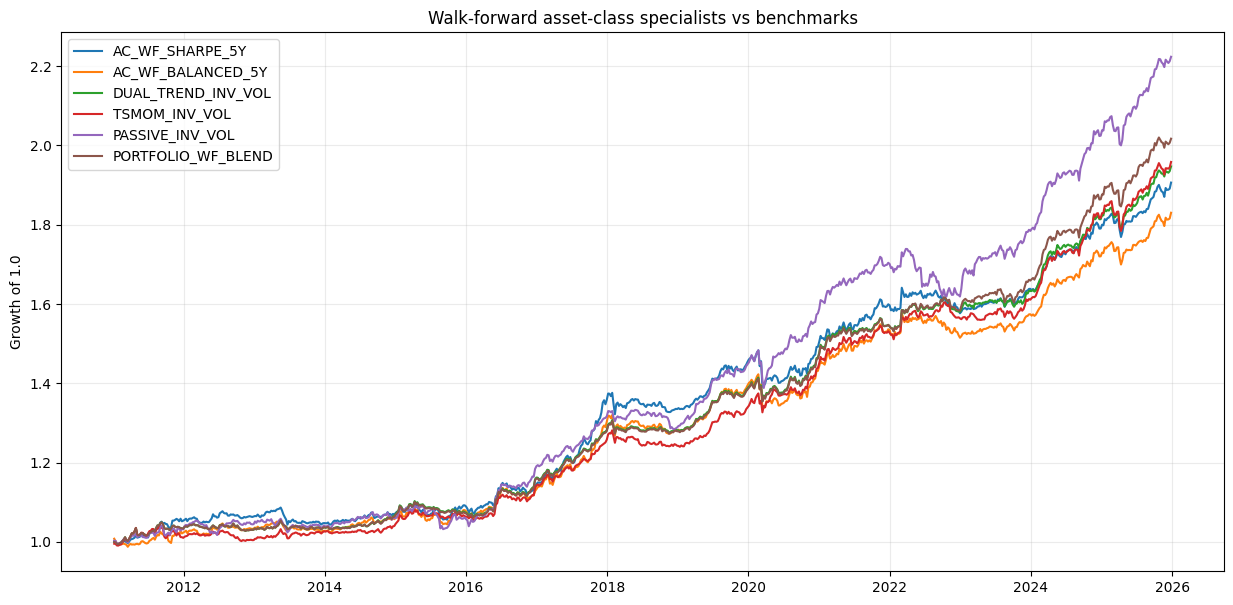

In [16]:
# ============================================================
# 11.16 — EQUITY CURVES
# ============================================================
plt.figure(figsize=(15, 7))

for name in comparison_panel.columns:
    eq = (1 + comparison_panel[name]).cumprod()
    plt.plot(eq.index, eq.values, label=name)

plt.title("Walk-forward asset-class specialists vs benchmarks")
plt.ylabel("Growth of 1.0")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


## 11.17 Drawdowns


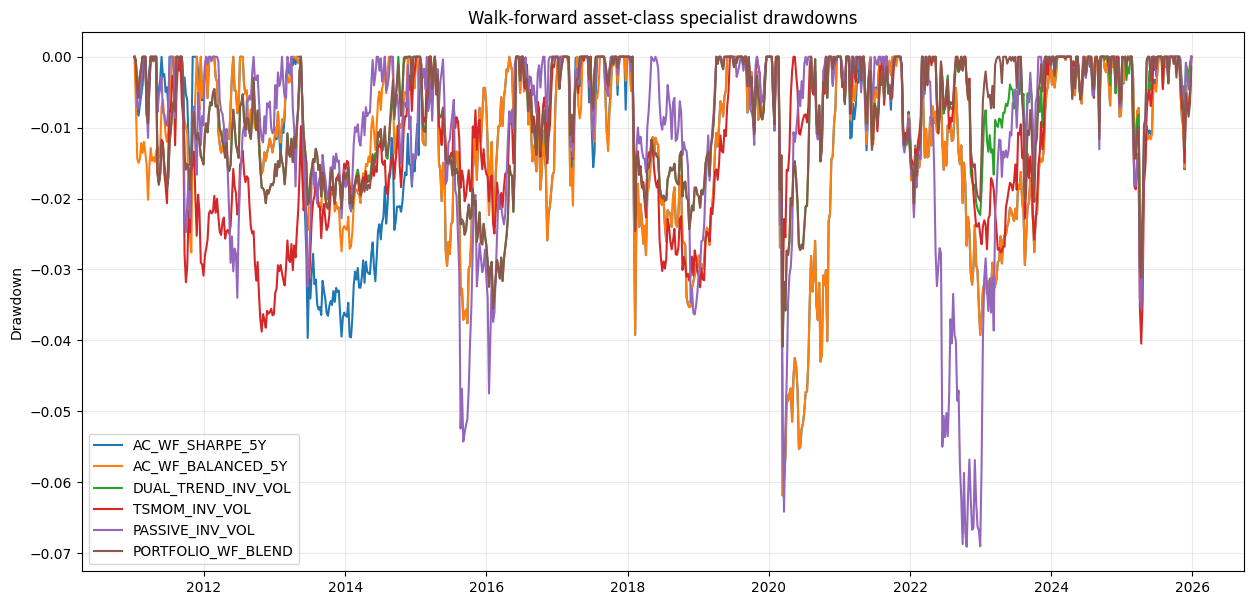

In [17]:
# ============================================================
# 11.17 — DRAWDOWNS
# ============================================================
plt.figure(figsize=(15, 7))

for name in comparison_panel.columns:
    eq = (1 + comparison_panel[name]).cumprod()
    dd = eq / eq.cummax() - 1
    plt.plot(dd.index, dd.values, label=name)

plt.title("Walk-forward asset-class specialist drawdowns")
plt.ylabel("Drawdown")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


## 11.18 OOS stress periods

Only stress periods within the walk-forward test era are considered here.


In [18]:
# ============================================================
# 11.18 — OOS STRESS PERIODS
# ============================================================
OOS_STRESS_PERIODS = {
    "Euro-area stress": ("2011-05-01", "2012-07-31"),
    "COVID crash": ("2020-02-01", "2020-04-30"),
    "2022 inflation/rates shock": ("2022-01-01", "2022-12-31"),
}

stress_rows = []

for period, (start, end) in OOS_STRESS_PERIODS.items():
    for name in comparison_panel.columns:
        r = comparison_panel[name].loc[start:end].dropna()

        if len(r) == 0:
            continue

        stress_rows.append({
            "period": period,
            "strategy": name,
            "weeks": len(r),
            "total_return": (1 + r).prod() - 1,
            "max_drawdown": max_drawdown(r),
            "worst_week": r.min(),
        })

stress = pd.DataFrame(stress_rows)
display(stress)


,period,strategy,weeks,total_return,max_drawdown,worst_week
0,Euro-area stress,AC_WF_SHARPE_5Y,65,0.055574,-0.015255,-0.007159
1,Euro-area stress,AC_WF_BALANCED_5Y,65,0.048101,-0.027600,-0.011171
2,Euro-area stress,DUAL_TREND_INV_VOL,65,0.004813,-0.018759,-0.016361
3,Euro-area stress,TSMOM_INV_VOL,65,-0.009795,-0.031804,-0.019208
4,Euro-area stress,PASSIVE_INV_VOL,65,0.022282,-0.033990,-0.019343
5,Euro-area stress,PORTFOLIO_WF_BLEND,65,0.004813,-0.018759,-0.016361
6,COVID crash,AC_WF_SHARPE_5Y,12,-0.028992,-0.061874,-0.044242
7,COVID crash,AC_WF_BALANCED_5Y,12,-0.028992,-0.061874,-0.044242
8,COVID crash,DUAL_TREND_INV_VOL,12,-0.002513,-0.040895,-0.027334
9,COVID crash,TSMOM_INV_VOL,12,0.012525,-0.034710,-0.021114


## 11.19 Asset-class selection frequencies

This table answers a core structural question:

> Which strategy does the walk-forward process actually choose most often for each asset class?


In [19]:
# ============================================================
# 11.19 — SELECTION FREQUENCIES
# ============================================================
def selection_frequency(selection_df):
    return (
        selection_df
        .groupby(["asset_class", "selected_strategy"])
        .size()
        .rename("years_selected")
        .reset_index()
    )

freq_sharpe = selection_frequency(sel_sharpe_5y)
freq_balanced = selection_frequency(sel_balanced_5y)

print("5Y Sharpe selector")
display(freq_sharpe)

print("5Y Balanced selector")
display(freq_balanced)


5Y Sharpe selector


,asset_class,selected_strategy,years_selected
0,commodities,DUAL_TREND_13_52,8
1,commodities,PASSIVE_LONG,2
2,commodities,SC_PT_REDUCE_25,2
3,commodities,TSMOM_52W,3
4,crypto,DUAL_TREND_13_52,9
5,crypto,PASSIVE_LONG,2
6,crypto,SC_PT_REDUCE_25,4
7,equities,DUAL_TREND_13_52,1
8,equities,PASSIVE_LONG,5
9,equities,SC_CORE,2


5Y Balanced selector


,asset_class,selected_strategy,years_selected
0,commodities,DUAL_TREND_13_52,9
1,commodities,PASSIVE_LONG,1
2,commodities,SC_PT_REDUCE_25,1
3,commodities,TSMOM_52W,4
4,crypto,DUAL_TREND_13_52,9
5,crypto,PASSIVE_LONG,2
6,crypto,SC_PT_REDUCE_25,4
7,equities,DUAL_TREND_13_52,1
8,equities,PASSIVE_LONG,5
9,equities,SC_CORE,1


## 11.20 Does the equity specialisation hypothesis survive OOS?

Notebook 10 suggested that SuperbCommand may be particularly effective in equities.

This section directly measures how often the walk-forward selector chooses:

- `SC_CORE`
- `SC_PT_REDUCE_25`

for equities.


In [20]:
# ============================================================
# 11.20 — EQUITY SPECIALISATION DIAGNOSTIC
# ============================================================
equity_rows = []

for label, selection_df in [
    ("sharpe_5y", sel_sharpe_5y),
    ("balanced_5y", sel_balanced_5y),
]:
    g = selection_df[
        selection_df["asset_class"] == "equities"
    ].copy()

    sc_share = g["selected_strategy"].isin(
        ["SC_CORE", "SC_PT_REDUCE_25"]
    ).mean()

    dual_share = (
        g["selected_strategy"] == "DUAL_TREND_13_52"
    ).mean()

    equity_rows.append({
        "selector": label,
        "test_years": len(g),
        "share_years_selecting_superbcommand": sc_share,
        "share_years_selecting_dual_trend": dual_share,
        "most_common_strategy": g["selected_strategy"].mode().iloc[0],
    })

equity_specialisation = pd.DataFrame(equity_rows)
display(equity_specialisation)


,selector,test_years,share_years_selecting_superbcommand,share_years_selecting_dual_trend,most_common_strategy
0,sharpe_5y,15,0.466667,0.066667,PASSIVE_LONG
1,balanced_5y,15,0.466667,0.066667,SC_PT_REDUCE_25


## 11.21 Parsimony comparison

A more complicated specialist architecture should earn its complexity.

Report the Sharpe increment relative to pure Dual Trend and the number of distinct strategy assignments made across the asset classes.


In [21]:
# ============================================================
# 11.21 — PARSIMONY / COMPLEXITY SUMMARY
# ============================================================
dual_ref = comparison_panel["DUAL_TREND_INV_VOL"]
dual_metrics = metrics(dual_ref)

parsimony_rows = []

for name, selection_df, r in [
    ("AC_WF_SHARPE_5Y", sel_sharpe_5y, comparison_panel["AC_WF_SHARPE_5Y"]),
    ("AC_WF_BALANCED_5Y", sel_balanced_5y, comparison_panel["AC_WF_BALANCED_5Y"]),
]:
    m = metrics(r)

    parsimony_rows.append({
        "strategy": name,
        "sharpe": m["sharpe"],
        "dual_sharpe": dual_metrics["sharpe"],
        "sharpe_gap_vs_dual": m["sharpe"] - dual_metrics["sharpe"],
        "cagr_gap_vs_dual": m["cagr"] - dual_metrics["cagr"],
        "max_drawdown_gap_vs_dual": m["max_drawdown"] - dual_metrics["max_drawdown"],
        "unique_assetclass_strategy_pairs_used": (
            selection_df[["asset_class", "selected_strategy"]]
            .drop_duplicates()
            .shape[0]
        ),
        "total_strategy_switches": int(
            selection_stability(selection_df)["switches"].sum()
        ),
    })

parsimony_summary = pd.DataFrame(parsimony_rows)
display(parsimony_summary)


,strategy,sharpe,dual_sharpe,sharpe_gap_vs_dual,cagr_gap_vs_dual,max_drawdown_gap_vs_dual,unique_assetclass_strategy_pairs_used,total_strategy_switches
0,AC_WF_SHARPE_5Y,1.127189,1.450324,-0.323135,-0.001469,-0.020979,20,34
1,AC_WF_BALANCED_5Y,1.074387,1.450324,-0.375936,-0.004294,-0.020979,20,28


## 11.22 Save outputs


In [22]:
# ============================================================
# 11.22 — SAVE OUTPUTS
# ============================================================
PRIMARY_PERF_PATH = PATHS["results"] / "11_primary_specialist_performance.csv"
SHARPE_SELECTION_PATH = PATHS["results"] / "11_sharpe_selector_selections.csv"
BALANCED_SELECTION_PATH = PATHS["results"] / "11_balanced_selector_selections.csv"
SHARPE_WEIGHTS_PATH = PATHS["results"] / "11_sharpe_selector_weights.csv"
BALANCED_WEIGHTS_PATH = PATHS["results"] / "11_balanced_selector_weights.csv"
STABILITY_SHARPE_PATH = PATHS["results"] / "11_sharpe_selector_stability.csv"
STABILITY_BALANCED_PATH = PATHS["results"] / "11_balanced_selector_stability.csv"
BENCHMARK_PATH = PATHS["results"] / "11_specialist_benchmark_comparison.csv"
WINDOW_PATH = PATHS["results"] / "11_specialist_window_sensitivity.csv"
ANNUAL_PATH = PATHS["results"] / "11_specialist_annual_returns.csv"
STRESS_PATH = PATHS["results"] / "11_specialist_stress_summary.csv"
FREQ_SHARPE_PATH = PATHS["results"] / "11_sharpe_selection_frequency.csv"
FREQ_BALANCED_PATH = PATHS["results"] / "11_balanced_selection_frequency.csv"
EQUITY_PATH = PATHS["results"] / "11_equity_specialisation_diagnostic.csv"
PARSIMONY_PATH = PATHS["results"] / "11_specialist_parsimony_summary.csv"

RETURNS_PATH = PATHS["data_processed"] / "11_asset_class_specialist_walkforward_returns.parquet"

primary_performance.to_csv(PRIMARY_PERF_PATH, index=False)
sel_sharpe_5y.to_csv(SHARPE_SELECTION_PATH, index=False)
sel_balanced_5y.to_csv(BALANCED_SELECTION_PATH, index=False)
w_sharpe_5y.to_csv(SHARPE_WEIGHTS_PATH, index=False)
w_balanced_5y.to_csv(BALANCED_WEIGHTS_PATH, index=False)
stability_sharpe.to_csv(STABILITY_SHARPE_PATH, index=False)
stability_balanced.to_csv(STABILITY_BALANCED_PATH, index=False)
benchmark_comparison.to_csv(BENCHMARK_PATH, index=False)
window_sensitivity.to_csv(WINDOW_PATH, index=False)
annual_returns.to_csv(ANNUAL_PATH, index=False)
stress.to_csv(STRESS_PATH, index=False)
freq_sharpe.to_csv(FREQ_SHARPE_PATH, index=False)
freq_balanced.to_csv(FREQ_BALANCED_PATH, index=False)
equity_specialisation.to_csv(EQUITY_PATH, index=False)
parsimony_summary.to_csv(PARSIMONY_PATH, index=False)

comparison_panel.to_parquet(RETURNS_PATH)

print("Saved Notebook 11 outputs.")


Saved Notebook 11 outputs.


## 11.23 Validation suite

Notebook 11 passes only if:

- 2026 remains absent;
- all five candidate strategies remain available;
- every asset class receives exactly one strategy per test year;
- every portfolio weight is estimated before the test year;
- annual asset-class weights sum to one;
- training windows precede test years;
- the primary 5-year selectors cover 2011–2025;
- all robustness windows remain pre-specified at 3/5/7 years;
- all output files are written.


In [23]:
# ============================================================
# 11.23 — VALIDATION SUITE
# ============================================================
checks = {}

checks["holdout_absent"] = comparison_panel.index.max() <= RESEARCH_END
checks["2026_absent"] = not (comparison_panel.index.year == 2026).any()

checks["five_candidate_strategies"] = (
    set(strategies) == EXPECTED_STRATEGIES
)

for name, selection_df in [
    ("sharpe", sel_sharpe_5y),
    ("balanced", sel_balanced_5y),
]:
    counts = selection_df.groupby("test_year")["asset_class"].nunique()
    checks[f"{name}_all_asset_classes_each_year"] = (
        counts.eq(len(asset_classes)).all()
    )

    checks[f"{name}_train_precedes_test"] = (
        selection_df["train_end_year"]
        < selection_df["test_year"]
    ).all()

for name, weight_df in [
    ("sharpe", w_sharpe_5y),
    ("balanced", w_balanced_5y),
]:
    sums = weight_df.groupby("test_year")["weight"].sum()
    checks[f"{name}_weights_sum_to_one"] = np.allclose(
        sums.values,
        np.ones(len(sums)),
        atol=1e-10
    )

expected_test_years = set(range(FIRST_TEST_YEAR, LAST_TEST_YEAR + 1))

checks["sharpe_primary_all_test_years"] = (
    set(sel_sharpe_5y["test_year"].unique()) == expected_test_years
)

checks["balanced_primary_all_test_years"] = (
    set(sel_balanced_5y["test_year"].unique()) == expected_test_years
)

checks["training_windows_fixed_3_5_7"] = TRAINING_WINDOWS == [3, 5, 7]

checks["outputs_written"] = all(
    p.exists()
    for p in [
        PRIMARY_PERF_PATH,
        SHARPE_SELECTION_PATH,
        BALANCED_SELECTION_PATH,
        SHARPE_WEIGHTS_PATH,
        BALANCED_WEIGHTS_PATH,
        STABILITY_SHARPE_PATH,
        STABILITY_BALANCED_PATH,
        BENCHMARK_PATH,
        WINDOW_PATH,
        ANNUAL_PATH,
        STRESS_PATH,
        FREQ_SHARPE_PATH,
        FREQ_BALANCED_PATH,
        EQUITY_PATH,
        PARSIMONY_PATH,
        RETURNS_PATH,
    ]
)

validation = pd.DataFrame({
    "check": list(checks.keys()),
    "passed": list(checks.values()),
})

print(validation.to_string(index=False))

if not all(checks.values()):
    failed = [k for k, v in checks.items() if not v]
    raise RuntimeError(f"Notebook 11 validation failed: {failed}")

print("\n" + "=" * 78)
print("NOTEBOOK 11 STATUS: PASS")
print("=" * 78)
print("Walk-forward asset-class strategy selection completed.")
print("No signal hyperparameters were optimised.")
print("All asset-class strategy choices were made using prior data only.")
print("2026 final holdout: NOT ACCESSED")
print("Review whether specialisation earns its added complexity.")


                               check  passed
                      holdout_absent    True
                         2026_absent    True
           five_candidate_strategies    True
  sharpe_all_asset_classes_each_year    True
          sharpe_train_precedes_test    True
balanced_all_asset_classes_each_year    True
        balanced_train_precedes_test    True
           sharpe_weights_sum_to_one    True
         balanced_weights_sum_to_one    True
       sharpe_primary_all_test_years    True
     balanced_primary_all_test_years    True
        training_windows_fixed_3_5_7    True
                     outputs_written    True

NOTEBOOK 11 STATUS: PASS
Walk-forward asset-class strategy selection completed.
No signal hyperparameters were optimised.
All asset-class strategy choices were made using prior data only.
2026 final holdout: NOT ACCESSED
Review whether specialisation earns its added complexity.


In [24]:
# ============================================================
# 11.24 — WRITE MANIFEST
# ============================================================
manifest = {
    "notebook_id": "11",
    "notebook_name": "Walk-Forward Asset-Class Strategy Selection",
    "project_name": "SuperbCommand – Multi-Asset CTA Strategy",
    "run_timestamp_utc": datetime.now(timezone.utc).isoformat(),
    "research_end": str(RESEARCH_END.date()),
    "holdout_start": str(HOLDOUT_START.date()),
    "holdout_accessed": False,
    "asset_classes": asset_classes,
    "candidate_strategies": strategies,
    "primary_training_years": PRIMARY_TRAIN_YEARS,
    "robustness_training_windows": TRAINING_WINDOWS,
    "selectors": [
        "Sharpe with Calmar tie-breaker",
        "Balanced average rank of Sharpe, Sortino and Calmar with Sharpe tie-breaker",
    ],
    "portfolio_method": "asset-class inverse volatility estimated from selected training sleeves",
    "test_frequency": "annual",
    "first_test_year": FIRST_TEST_YEAR,
    "last_test_year": LAST_TEST_YEAR,
    "signal_hyperparameters_optimised": False,
    "outputs": {
        "primary_performance": str(PRIMARY_PERF_PATH),
        "sharpe_selections": str(SHARPE_SELECTION_PATH),
        "balanced_selections": str(BALANCED_SELECTION_PATH),
        "sharpe_weights": str(SHARPE_WEIGHTS_PATH),
        "balanced_weights": str(BALANCED_WEIGHTS_PATH),
        "sharpe_stability": str(STABILITY_SHARPE_PATH),
        "balanced_stability": str(STABILITY_BALANCED_PATH),
        "benchmark_comparison": str(BENCHMARK_PATH),
        "window_sensitivity": str(WINDOW_PATH),
        "annual_returns": str(ANNUAL_PATH),
        "stress_summary": str(STRESS_PATH),
        "sharpe_selection_frequency": str(FREQ_SHARPE_PATH),
        "balanced_selection_frequency": str(FREQ_BALANCED_PATH),
        "equity_specialisation": str(EQUITY_PATH),
        "parsimony_summary": str(PARSIMONY_PATH),
        "walkforward_returns": str(RETURNS_PATH),
    },
    "status": "PASS",
}

MANIFEST_PATH = PATHS["manifests"] / "11_asset_class_walkforward_selection_manifest.json"

with open(MANIFEST_PATH, "w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=2)

print("Saved manifest:")
print(MANIFEST_PATH)


Saved manifest:
/content/drive/MyDrive/Colab Notebooks/SuperbCommand/Multi-Asset CTA Strategy/manifests/11_asset_class_walkforward_selection_manifest.json


---

# End of Notebook 11

## Main research question

\[
\boxed{\text{Can asset-class-specific strategy selection improve the portfolio out of sample?}}
\]

Notebook 11 tests the specialisation hypothesis sequentially rather than using the hindsight winner map from Notebook 10.

### Principal comparison

The dynamic specialist architecture must justify itself relative to:

\[
\boxed{\text{Dual Trend 13/52 + hierarchical inverse volatility}}
\]

and the existing portfolio-level WF blend selector.

### Interpretation rule

If specialist selection produces only a tiny Sharpe improvement while adding substantial switching and complexity, prefer the simpler architecture.

If it produces a persistent OOS improvement across 3/5/7-year windows and both selection rules, specialisation becomes a serious candidate for the frozen architecture.

### Final holdout

**2026 remains completely untouched.**
